In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
FOLDER = '/content/drive/MyDrive/CPI_Research'
os.makedirs(FOLDER, exist_ok=True)
print("✅ Drive mounted:", os.listdir(FOLDER))

Mounted at /content/drive
✅ Drive mounted: ['bangladesh_MASTER_dataset.csv']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, warnings, json
warnings.filterwarnings('ignore')

from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEED = 42
np.random.seed(SEED)
print("✅ Ready. Seed fixed at", SEED)

✅ Ready. Seed fixed at 42


In [ ]:
df = pd.read_csv(f'{FOLDER}/bangladesh_MASTER_dataset.csv',
                 index_col=0, parse_dates=True)

# Derive inflation directly from CPI (305 points, back to 2001)
df['Inflation_from_CPI'] = (df['CPI'].pct_change(12) * 100)

# ── WINDOWS ──────────────────────────────────────────────
TRAIN_END  = '2020-12-01'
TEST_START = '2021-01-01'
TEST_END   = '2026-04-01'   # last month where ALL variables exist

y_full = df['CPI'].loc['2000-01-01':TEST_END]          # univariate target
y_train = y_full.loc[:TRAIN_END]
y_test  = y_full.loc[TEST_START:]

EXOG = ['ExchangeRate_BDT_USD','Forex_Reserves_USDmn','BroadMoney_BDTmn',
        'Brent_Oil_USD','Fed_Funds_Rate','Gold_Price_Index',
        'FAO_Food_Index','FAO_Cereals_Index',
        'COVID_dummy','UkraineWar_dummy','BD_Unrest_dummy']

print(f"Univariate  → train {len(y_train)} months | test {len(y_test)} months")
print(f"Test window covers the 2022–23 inflation crisis ✅")

Univariate  → train 252 months | test 64 months
Test window covers the 2022–23 inflation crisis ✅


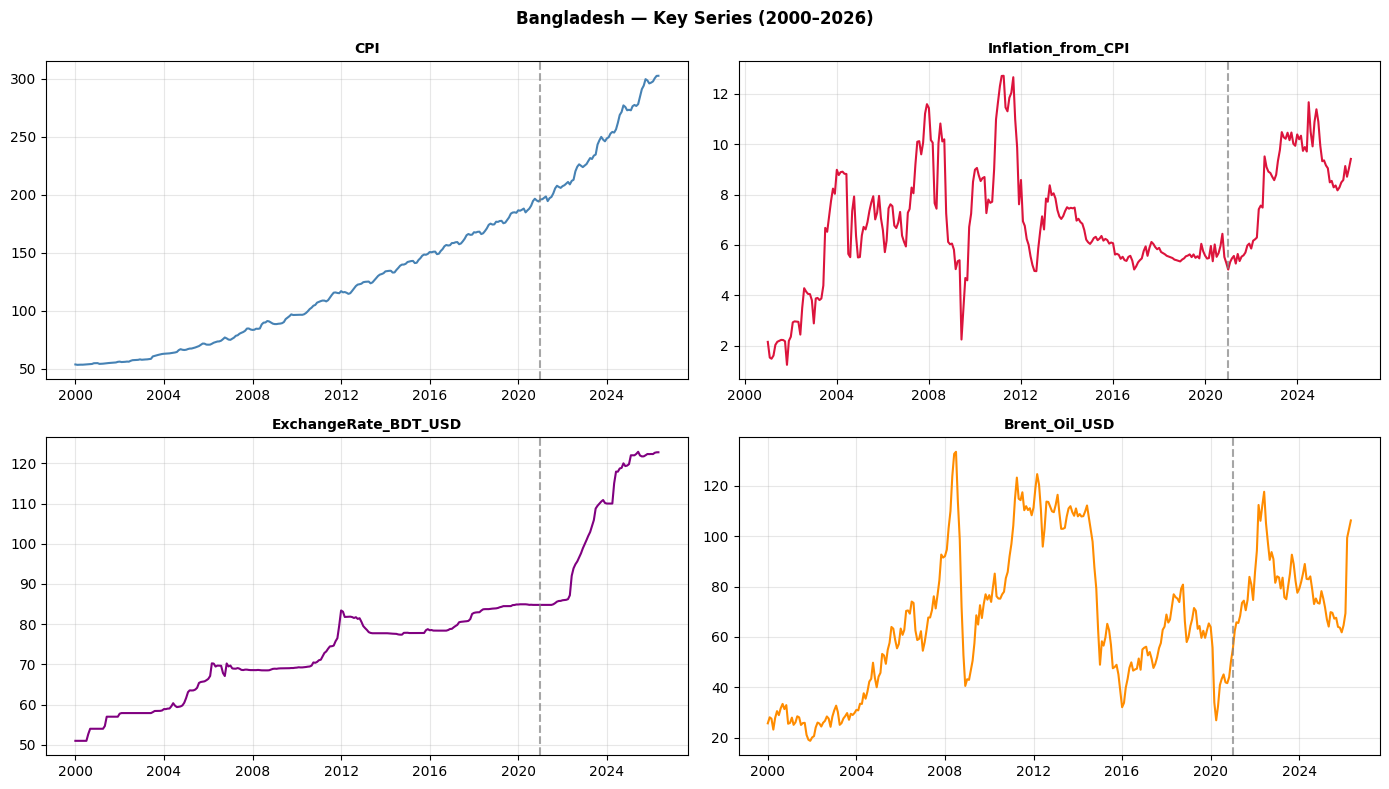

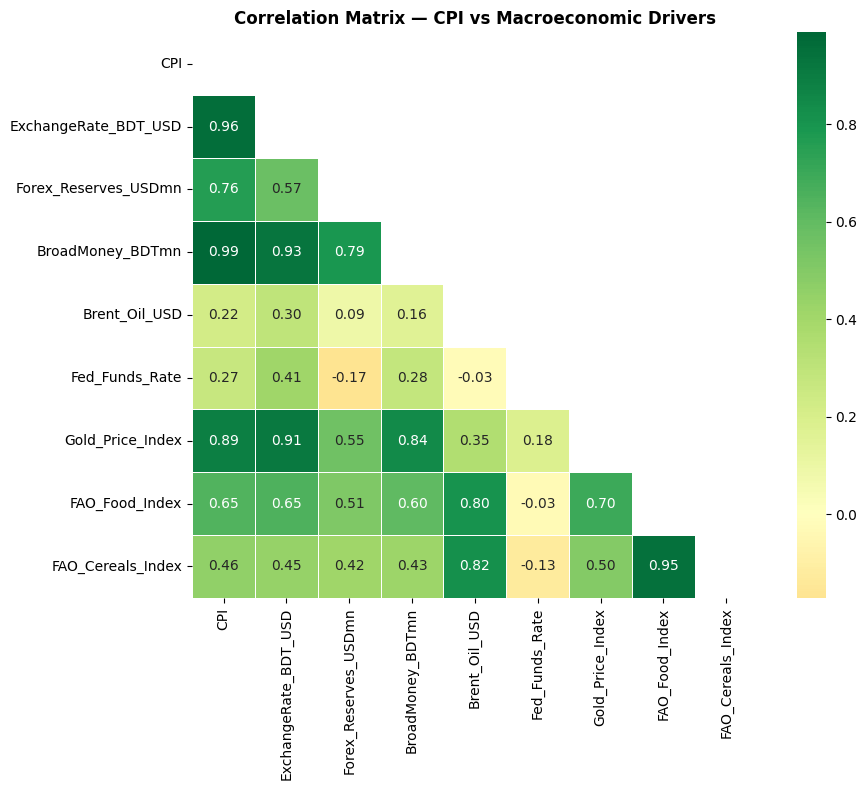

✅ Two paper figures saved to Drive


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Bangladesh — Key Series (2000–2026)', fontweight='bold')
for ax, col, color in zip(axes.flat,
        ['CPI','Inflation_from_CPI','ExchangeRate_BDT_USD','Brent_Oil_USD'],
        ['steelblue','crimson','purple','darkorange']):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, lw=1.5)
    ax.axvline(pd.Timestamp(TEST_START), color='gray', ls='--', alpha=0.7)
    ax.set_title(col, fontsize=10, fontweight='bold'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FOLDER}/fig_eda_series.png', dpi=150, bbox_inches='tight')
plt.show()

core = df.loc['2002-01-01':TEST_END, ['CPI'] + EXOG[:8]]
plt.figure(figsize=(10, 8))
sns.heatmap(core.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=np.triu(np.ones((9,9), dtype=bool)), square=True, linewidths=.5)
plt.title('Correlation Matrix — CPI vs Macroeconomic Drivers', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FOLDER}/fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Two paper figures saved to Drive")

In [ ]:
RESULTS_PATH = f'{FOLDER}/all_model_results.csv'
results_log = []

def log_result(name, actual, pred):
    a, p = np.asarray(actual, float).ravel(), np.asarray(pred, float).ravel()
    row = {'Model': name,
           'R2':   round(r2_score(a, p), 4),
           'RMSE': round(np.sqrt(mean_squared_error(a, p)), 4),
           'MAE':  round(mean_absolute_error(a, p), 4),
           'MAPE': round(np.mean(np.abs((a-p)/a))*100, 3)}
    results_log.append(row)
    pd.DataFrame(results_log).to_csv(RESULTS_PATH, index=False)
    print(f"✅ {name}:  R²={row['R2']}  RMSE={row['RMSE']}  MAE={row['MAE']}  MAPE={row['MAPE']}%  → saved")
    return row

print("✅ Logger ready — writes to Drive after every model")

✅ Logger ready — writes to Drive after every model


In [ ]:
best = {'aic': np.inf}
for p, d, q in itertools.product(range(4), range(3), range(4)):
    try:
        r = SARIMAX(y_train, order=(p,d,q),
                    enforce_stationarity=False, enforce_invertibility=False
                    ).fit(disp=False)
        if r.aic < best['aic']:
            best = {'aic': r.aic, 'order': (p,d,q), 'res': r}
    except Exception:
        pass
print(f"Best ARIMA order: {best['order']}  (AIC={best['aic']:.1f})")

# One-step-ahead rolling forecast over test (no refit, true lags used)
ext = best['res'].append(y_test, refit=False)
arima_pred = ext.get_prediction(start=y_test.index[0]).predicted_mean
log_result(f"ARIMA{best['order']}", y_test, arima_pred)
ARIMA_ORDER = best['order']   # saved for hybrid sessions

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Best ARIMA order: (3, 2, 3)  (AIC=639.9)
✅ ARIMA(3, 2, 3):  R²=0.994  RMSE=2.6239  MAE=1.9146  MAPE=0.786%  → saved


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
best_s = {'aic': np.inf}
for (p,d,q), (P,D,Q) in itertools.product(
        itertools.product(range(3), range(2), range(3)),
        itertools.product(range(2), range(2), range(2))):
    try:
        r = SARIMAX(y_train, order=(p,d,q), seasonal_order=(P,D,Q,12),
                    enforce_stationarity=False, enforce_invertibility=False
                    ).fit(disp=False)
        if r.aic < best_s['aic']:
            best_s = {'aic': r.aic, 'order': (p,d,q), 'sorder': (P,D,Q,12), 'res': r}
    except Exception:
        pass
print(f"Best SARIMA: {best_s['order']} x {best_s['sorder']}  (AIC={best_s['aic']:.1f})")

ext_s = best_s['res'].append(y_test, refit=False)
sarima_pred = ext_s.get_prediction(start=y_test.index[0]).predicted_mean
log_result(f"SARIMA{best_s['order']}x{best_s['sorder']}", y_test, sarima_pred)
SARIMA_ORDER, SARIMA_SORDER = best_s['order'], best_s['sorder']

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Li

Best SARIMA: (2, 1, 2) x (0, 1, 1, 12)  (AIC=398.3)
✅ SARIMA(2, 1, 2)x(0, 1, 1, 12):  R²=0.9985  RMSE=1.3053  MAE=0.937  MAPE=0.384%  → saved


In [ ]:
# Predict CPI_t from: CPI lags 1-12  +  exogenous lagged 1 month
sup = pd.DataFrame(index=df.index)
sup['y'] = df['CPI']
for L in range(1, 13):
    sup[f'CPI_lag{L}'] = df['CPI'].shift(L)
for c in EXOG:
    sup[f'{c}_lag1'] = df[c].shift(1)

sup = sup.loc['2003-01-01':TEST_END].dropna()   # all lags valid, all vars present

Xtr = sup.loc[:TRAIN_END].drop(columns='y');  ytr = sup.loc[:TRAIN_END,'y']
Xte = sup.loc[TEST_START:].drop(columns='y'); yte = sup.loc[TEST_START:,'y']

scaler = StandardScaler().fit(Xtr)             # fit on TRAIN ONLY — no leakage
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
print(f"Supervised set → train {Xtr.shape}, test {Xte.shape} ✅")

Supervised set → train (216, 23), test (64, 23) ✅


In [ ]:
lasso = LassoCV(cv=5, random_state=SEED, max_iter=50000).fit(Xtr_s, ytr)
lasso_pred = lasso.predict(Xte_s)
log_result('LASSO', yte, lasso_pred)

coef = pd.Series(lasso.coef_, index=Xtr.columns)
sel = coef[coef != 0].sort_values(key=abs, ascending=False)
print(f"\nLASSO selected {len(sel)}/{len(coef)} features (Gap #3 — interpretability):")
print(sel.round(3).to_string())
sel.to_csv(f'{FOLDER}/lasso_selected_features.csv')

✅ LASSO:  R²=0.977  RMSE=5.1332  MAE=4.3137  MAPE=1.676%  → saved

LASSO selected 7/23 features (Gap #3 — interpretability):
CPI_lag1                     22.770
CPI_lag11                     9.168
CPI_lag12                     7.449
BroadMoney_BDTmn_lag1         0.696
FAO_Food_Index_lag1           0.681
Forex_Reserves_USDmn_lag1     0.525
Gold_Price_Index_lag1         0.021


In [ ]:
mars_pred, mars_name = None, None
try:
    !pip install sklearn-contrib-py-earth -q
    from pyearth import Earth
    mars = Earth(max_degree=2).fit(Xtr_s, ytr)
    mars_pred, mars_name = mars.predict(Xte_s), 'MARS (py-earth)'
    print("✅ True py-earth MARS ran")
except Exception as e:
    print(f"py-earth unavailable ({type(e).__name__}) → spline-LASSO fallback (MARS-class method)")
    pipe = Pipeline([
        ('spline', SplineTransformer(degree=2, n_knots=5)),
        ('select', LassoCV(cv=5, random_state=SEED, max_iter=50000)),
    ]).fit(Xtr_s, ytr)
    mars_pred, mars_name = pipe.predict(Xte_s), 'MARS-Spline-LASSO'

log_result(mars_name, yte, mars_pred)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
py-earth unavailable (ModuleNotFoundError) → spline-LASSO fallback (MARS-class method)
✅ MARS-Spline-LASSO:  R²=-2.4049  RMSE=62.4999  MAE=52.1012  MAPE=19.803%  → saved


{'Model': 'MARS-Spline-LASSO',
 'R2': -2.4049,
 'RMSE': np.float64(62.4999),
 'MAE': 52.1012,
 'MAPE': np.float64(19.803)}

In [ ]:
# CELL 10 (FIXED) — MARS-class model on CPI CHANGES (extrapolation-safe)
ytr_diff = ytr - Xtr['CPI_lag1']          # train target: monthly change
pipe = Pipeline([
    ('spline', SplineTransformer(degree=2, n_knots=5, extrapolation='linear')),
    ('select', LassoCV(cv=5, random_state=SEED, max_iter=50000)),
]).fit(Xtr_s, ytr_diff)

mars_pred = Xte['CPI_lag1'].values + pipe.predict(Xte_s)   # change + last value
mars_name = 'MARS-Spline-LASSO (diff)'
log_result(mars_name, yte, mars_pred)

✅ MARS-Spline-LASSO (diff):  R²=0.9932  RMSE=2.7923  MAE=2.1712  MAPE=0.886%  → saved


{'Model': 'MARS-Spline-LASSO (diff)',
 'R2': 0.9932,
 'RMSE': np.float64(2.7923),
 'MAE': 2.1712,
 'MAPE': np.float64(0.886)}

SESSION 1 RESULTS — sorted by RMSE
                        Model      R2    RMSE     MAE   MAPE
SARIMA(2, 1, 2)x(0, 1, 1, 12)  0.9985  1.3053  0.9370  0.384
               ARIMA(3, 2, 3)  0.9940  2.6239  1.9146  0.786
     MARS-Spline-LASSO (diff)  0.9932  2.7923  2.1712  0.886
                        LASSO  0.9770  5.1332  4.3137  1.676
            MARS-Spline-LASSO -2.4049 62.4999 52.1012 19.803

🏆 Session 1 leader: SARIMA(2, 1, 2)x(0, 1, 1, 12)


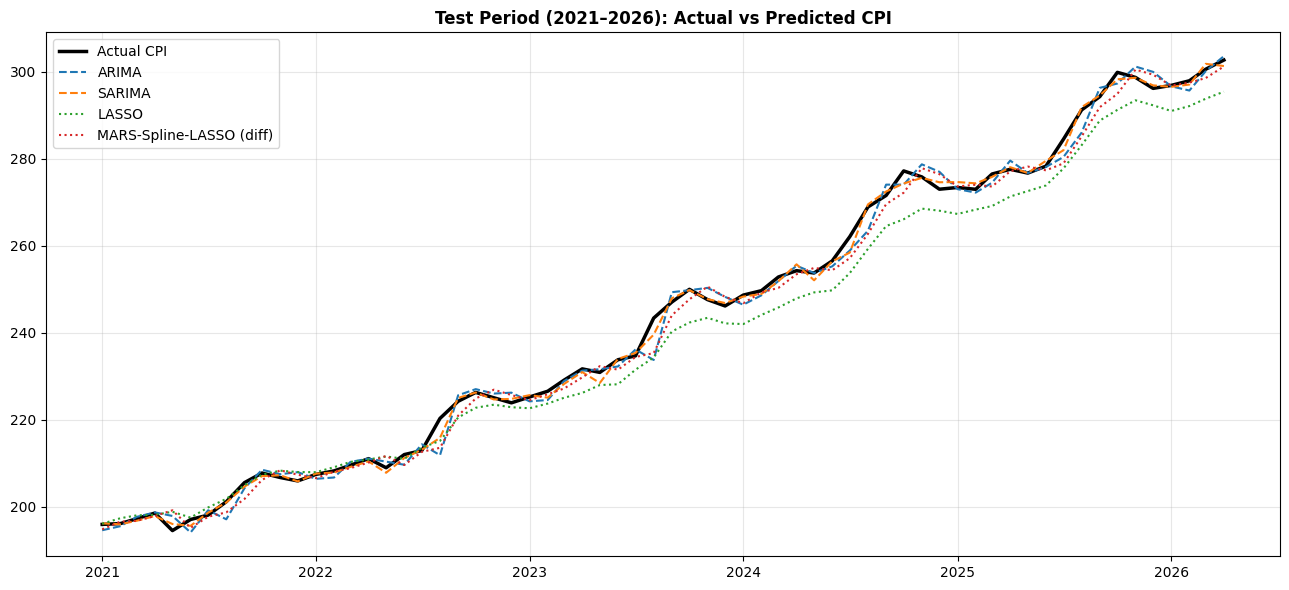

✅ Session 1 complete — everything saved to Drive


In [ ]:
res = pd.DataFrame(results_log).sort_values('RMSE')
print("="*58); print("SESSION 1 RESULTS — sorted by RMSE"); print("="*58)
print(res.to_string(index=False))
print(f"\n🏆 Session 1 leader: {res.iloc[0]['Model']}")

plt.figure(figsize=(13,6))
plt.plot(y_test.index, y_test, 'k-', lw=2.5, label='Actual CPI')
plt.plot(y_test.index, arima_pred,  '--', label='ARIMA')
plt.plot(y_test.index, sarima_pred, '--', label='SARIMA')
plt.plot(yte.index, lasso_pred, ':',  label='LASSO')
plt.plot(yte.index, mars_pred,  ':',  label=mars_name)
plt.title('Test Period (2021–2026): Actual vs Predicted CPI', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{FOLDER}/fig_session1_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

json.dump({'ARIMA_ORDER': ARIMA_ORDER, 'SARIMA_ORDER': SARIMA_ORDER,
           'SARIMA_SORDER': SARIMA_SORDER},
          open(f'{FOLDER}/session1_orders.json','w'))
print("✅ Session 1 complete — everything saved to Drive")

In [ ]:
res = pd.DataFrame(results_log)
res = res[res['Model'] != 'MARS-Spline-LASSO']   # drop the failed run
results_log = res.to_dict('records')
res.to_csv(RESULTS_PATH, index=False)
print(res.to_string(index=False))

                        Model     R2   RMSE    MAE  MAPE
               ARIMA(3, 2, 3) 0.9940 2.6239 1.9146 0.786
SARIMA(2, 1, 2)x(0, 1, 1, 12) 0.9985 1.3053 0.9370 0.384
                        LASSO 0.9770 5.1332 4.3137 1.676
     MARS-Spline-LASSO (diff) 0.9932 2.7923 2.1712 0.886


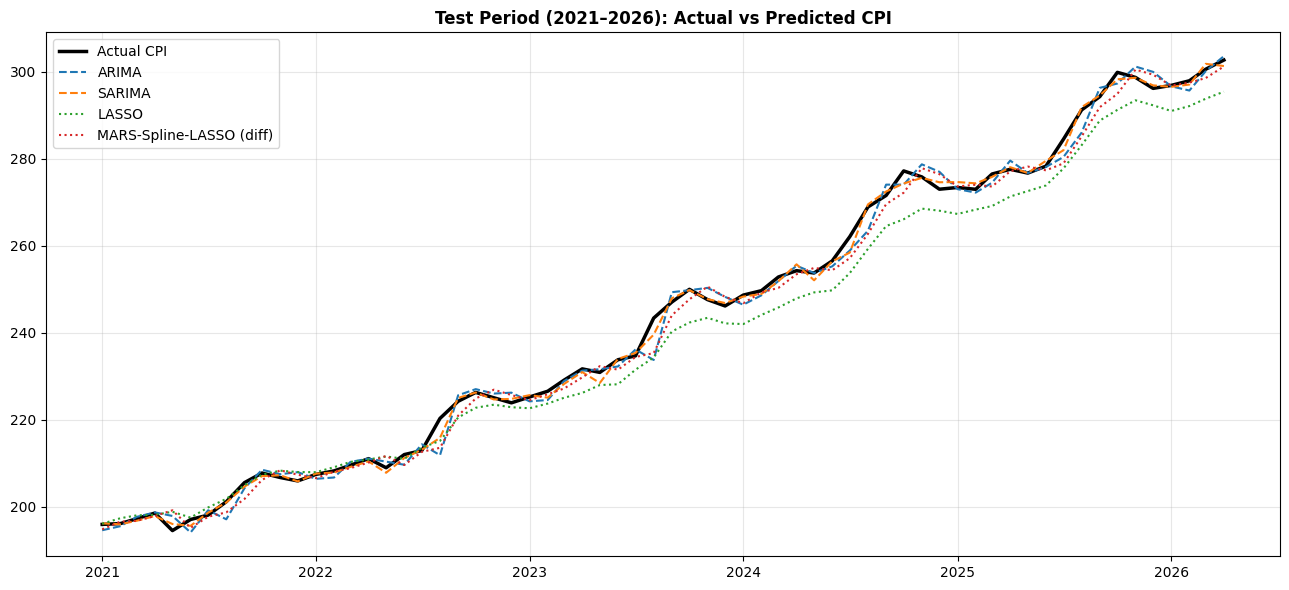

In [ ]:
plt.figure(figsize=(13,6))
plt.plot(y_test.index, y_test, 'k-', lw=2.5, label='Actual CPI')
plt.plot(y_test.index, arima_pred,  '--', label='ARIMA')
plt.plot(y_test.index, sarima_pred, '--', label='SARIMA')
plt.plot(yte.index, lasso_pred, ':',  label='LASSO')
plt.plot(yte.index, mars_pred,  ':',  label='MARS-Spline-LASSO (diff)')
plt.title('Test Period (2021–2026): Actual vs Predicted CPI', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{FOLDER}/fig_session1_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import os
print("Files in CPI_Research folder:\n")
for f in sorted(os.listdir(FOLDER)):
    size = os.path.getsize(f'{FOLDER}/{f}') / 1024
    print(f"  {'✅' if size > 0 else '❌ EMPTY'} {f}  ({size:.0f} KB)")

Files in CPI_Research folder:

  ✅ all_model_results.csv  (0 KB)
  ✅ bangladesh_MASTER_dataset.csv  (29 KB)
  ✅ fig_correlation.png  (132 KB)
  ✅ fig_eda_series.png  (190 KB)
  ✅ fig_session1_predictions.png  (147 KB)
  ✅ lasso_selected_features.csv  (0 KB)
  ✅ session1_orders.json  (0 KB)
